**Review**

Inconsistencies:

1. Add **evaluation megtric from Kaggle**: https://www.kaggle.com/competitions/ts-forecasting/overview

2.  **Leakage**: in load_feature_set, the scaler is fit globally across all training groups:

pythonscaler = RobustScaler().fit(all_train)

global scaler's median/IQR is computed from all series pooled together, which leaks distribution information across groups AND it is bad for sequential requirement

3.  The target column y_target is used as the first input feature

pythonmodel_cols = [TARGET_COL] + feature_cols   # y_target is channel 0

At position i in the sequence, you include y_target at time steps i through i+SEQ_LEN-1, and predict y_target at step i+SEQ_LEN. This is fine during training since those past targets are known. But at test time, the competition's test rows are future observations — you don't have the historical y_target values for the test group unless you reconstruct them from the training tail. **This is exactly what group_tails.pkl is meant to solve, but Block B/C/D never update or save it for the new feature sets.**


# CNN Experiments — Blocks B, C, D

This notebook assumes Block A (baseline CNN) has already been run and the following files have been saved:
- `best_cnn.pt` -- best model weights
- `scaler.pkl` -- fitted scaler
- `group_tails.pkl` -- group tails for inference
- `X_train, y_train, X_val, y_val` -- training and validation arrays in memory

Each block changes **one variable** at a time; everything else is kept fixed.

## Table of Contents
- [0 - Imports and Shared Utilities](#0)
- [1 - Block B: Feature Sets](#1)
- [2 - Block C: Training Hyperparameters](#2)
    - [2.1 - C1: Optimizer](#2-1)
    - [2.2 - C2: Learning Rate](#2-2)
    - [2.3 - C3: Batch Size](#2-3)
    - [2.4 - C4: LR Scheduler](#2-4)
    - [2.5 - C5: Early Stopping Patience](#2-5)
- [3 - Block D: Architecture Depth and Regularization](#3)
    - [3.1 - D1: Number of Layers](#3-1)
    - [3.2 - D2: Number of Filters](#3-2)
    - [3.3 - D3: Dropout](#3-3)
    - [3.4 - D4: Batch Normalization](#3-4)
- [4 - Summary Table](#4)

<a name="0"></a>
## 0 - Imports and Shared Utilities

In [12]:
# В Jupyter / VS Code / Cursor: встраивать графики в вывод ячейки (иначе иногда «пустой» рисунок)
%matplotlib inline

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import copy, time, warnings
warnings.filterwarnings("ignore")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device: " + str(DEVICE))


Device: cpu


In [13]:
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("Device: " + str(DEVICE))


Device: mps


In [14]:
# Shared constants (must match Block A)
INPUT_SIZE  = 30   # 1 target + 29 features
SEQ_LEN     = 20
EPOCHS      = 40   # max; early stopping will cut it short
PATIENCE    = 6

# Block A best config — carried forward as fixed baseline for B, C, D
BEST_A_NUM_FILTERS  = 64
BEST_A_KERNEL_SIZE  = 3
BEST_A_NUM_LAYERS   = 3
BEST_A_DROPOUT      = 0.2
BEST_A_BATCH_SIZE   = 256
BEST_A_LR           = 1e-3
BEST_A_OPTIMIZER    = "Adam"
BEST_A_SCHEDULER    = "ReduceOnPlateau"
BEST_A_FEATURE_SET  = "set_global_uncorr"  # placeholder; Block B picks the winner


In [15]:
# Experiment log — every run appends one row, never overwrite
results_log = []   # list of dicts → DataFrame at the end

def log_run(run_id, block, model_name, feature_set, optimizer_name,
            lr, batch_size, epochs_run, val_mae, val_rmse, extra=""):
    results_log.append({
        "run_id":      run_id,
        "block":       block,
        "model":       model_name,
        "feature_set": feature_set,
        "optimizer":   optimizer_name,
        "lr":          lr,
        "batch_size":  batch_size,
        "epochs_run":  epochs_run,
        "val_mae":     round(val_mae, 5),
        "val_rmse":    round(val_rmse, 5),
        "extra":       extra,
    })
    print(f"[{run_id}] MAE={val_mae:.5f}  RMSE={val_rmse:.5f}  epochs={epochs_run}")

def show_log():
    df = pd.DataFrame(results_log)
    display(df.sort_values(["block", "val_mae"]).reset_index(drop=True))
    return df


In [16]:
# Model definition (same as Block A)
class ResidualBlock(nn.Module):
    def __init__(self, channels, kernel_size, dropout):
        """
        Single residual block with two Conv1d layers and BatchNorm.

        Arguments:
        channels -- number of input and output channels, integer
        kernel_size -- convolutional kernel size, integer
        dropout -- dropout probability, scalar
        """
        super().__init__()
        pad = kernel_size // 2
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, padding=pad),
            nn.BatchNorm1d(channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(channels, channels, kernel_size, padding=pad),
            nn.BatchNorm1d(channels),
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(x + self.block(x))


class CNNForecaster(nn.Module):
    def __init__(self, input_size=INPUT_SIZE, num_filters=64,
                 kernel_size=3, num_layers=3, dropout=0.2):
        """
        1D CNN forecaster with residual blocks and global average pooling.

        Arguments:
        input_size -- number of input channels (features), integer
        num_filters -- number of convolutional filters per layer, integer
        kernel_size -- convolutional kernel size, integer
        num_layers -- number of residual blocks, integer
        dropout -- dropout probability, scalar
        """
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Conv1d(input_size, num_filters, kernel_size=1),
            nn.BatchNorm1d(num_filters),
            nn.ReLU(),
        )
        self.blocks = nn.Sequential(*[
            ResidualBlock(num_filters, kernel_size, dropout)
            for _ in range(num_layers)
        ])
        self.gap  = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Linear(num_filters, num_filters // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(num_filters // 2, 1),
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.blocks(x)
        x = self.gap(x).squeeze(-1)
        return self.head(x).squeeze(-1)


class TSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]


In [17]:
# Generic train + eval function
def make_optimizer(name, params, lr, weight_decay=1e-5):
    """
    Instantiate an optimizer by name.

    Arguments:
    name -- optimizer name, string ("Adam", "SGD", "RMSProp")
    params -- model parameters to optimize
    lr -- learning rate, scalar
    weight_decay -- L2 regularization coefficient, scalar

    Returns:
    optimizer -- torch.optim optimizer instance
    """
    if name == "Adam":     return torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)
    if name == "SGD":      return torch.optim.SGD(params,  lr=lr, weight_decay=weight_decay, momentum=0.9)
    if name == "RMSProp":  return torch.optim.RMSprop(params, lr=lr, weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer: {name}")


def make_scheduler(name, optimizer):
    """
    Instantiate a learning rate scheduler by name.

    Arguments:
    name -- scheduler name, string ("ReduceOnPlateau", "StepLR", "CosineAnnealing", "None")
    optimizer -- optimizer instance to attach the scheduler to

    Returns:
    scheduler -- torch.optim.lr_scheduler instance, or None
    """
    if name == "ReduceOnPlateau":   return torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", factor=0.5, patience=3)
    if name == "StepLR":            return torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    if name == "CosineAnnealing":   return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    if name == "None":              return None
    raise ValueError(f"Unknown scheduler: {name}")


def train_and_eval(model, train_loader, val_loader,
                   optimizer_name="Adam", lr=1e-3,
                   scheduler_name="ReduceOnPlateau",
                   patience=PATIENCE, epochs=EPOCHS,
                   save_path="best_exp.pt"):
    """
    Train the model and evaluate on validation set after each epoch.

    Arguments:
    model -- CNNForecaster instance to train
    train_loader -- DataLoader for the training set
    val_loader -- DataLoader for the validation set
    optimizer_name -- name of the optimizer to use, string ("Adam", "SGD", "RMSProp")
    lr -- learning rate, scalar
    scheduler_name -- name of the LR scheduler, string
    patience -- early stopping patience, integer
    epochs -- maximum number of training epochs, integer
    save_path -- file path to save the best model weights, string

    Returns:
    best_mae -- best validation MAE achieved, scalar
    best_rmse -- best validation RMSE achieved, scalar
    epochs_run -- number of epochs completed, integer
    history -- dictionary containing lists of train loss, val loss, and val MAE
    """
    if len(train_loader) == 0:
        raise RuntimeError("train_loader has 0 batches — no training rows. Check load_feature_set / N_SAMPLE_GROUPS.")
    if len(val_loader) == 0:
        raise RuntimeError("val_loader has 0 batches — cannot validate.")

    criterion = nn.HuberLoss(delta=1.0)
    optimizer = make_optimizer(optimizer_name, model.parameters(), lr)
    scheduler = make_scheduler(scheduler_name, optimizer)

    best_val_loss = float("inf")
    best_mae = best_rmse = float("inf")
    patience_ctr = 0
    history = {"train": [], "val": [], "mae": []}
    epoch_run = 0

    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        train_loss_total, n = 0.0, 0
        for X_batch, Y_batch in train_loader:
            X_batch, Y_batch = X_batch.to(DEVICE), Y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), Y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss_total += loss.item() * len(Y_batch); n += len(Y_batch)
        train_loss = train_loss_total / n

        # Val
        model.eval()
        val_loss_total, n = 0.0, 0
        predictions_list, targets_list = [], []
        with torch.no_grad():
            for X_batch, Y_batch in val_loader:
                X_batch, Y_batch = X_batch.to(DEVICE), Y_batch.to(DEVICE)
                p = model(X_batch)
                val_loss_total += criterion(p, Y_batch).item() * len(Y_batch); n += len(Y_batch)
                predictions_list.append(p.cpu()); targets_list.append(Y_batch.cpu())
        val_loss = val_loss_total / n
        predictions = torch.cat(predictions_list); targets = torch.cat(targets_list)
        val_mae  = torch.mean(torch.abs(predictions - targets)).item()
        val_rmse = torch.sqrt(torch.mean((predictions - targets) ** 2)).item()

        # Scheduler step
        if scheduler is not None:
            if scheduler_name == "ReduceOnPlateau":
                scheduler.step(val_loss)
            else:
                scheduler.step()

        history["train"].append(train_loss)
        history["val"].append(val_loss)
        history["mae"].append(val_mae)
        epoch_run = epoch

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_mae  = val_mae
            best_rmse = val_rmse
            patience_ctr = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_ctr += 1

        if epoch % 5 == 0 or patience_ctr >= patience:
            print(f"  ep {epoch:3d} | train={train_loss:.5f} val={val_loss:.5f} MAE={val_mae:.5f}")

        if patience_ctr >= patience:
            print(f"  → Early stop at epoch {epoch}")
            break

    return best_mae, best_rmse, epoch_run, history


def plot_history(history, title):
    n = len(history.get("train", []))
    if n == 0:
        print(
            f"[plot_history] Нет точек для «{title}»: история обучения пуста. "
            "Обычно это значит, что до train_and_eval не дошло ни одной эпохи "
            "(ошибка выше, EPOCHS=0, или ячейка с графиком выполнена без обучения / не тем hist)."
        )
        return
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    axes[0].plot(history["train"], label="train"); axes[0].plot(history["val"], label="val")
    axes[0].set_title(f"{title} — Huber loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(history["mae"], color="orange", label="val MAE")
    axes[1].set_title(f"{title} — Val MAE"); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()


<a name="1"></a>
## 1 - Block B: Feature Sets

**Fixed:** best CNN architecture from Block A, default hyperparameters.  
**Variable:** which feature-set parquet to use (files in `data/`).

| Exp | Feature set | Description |
|-----|-------------|-------------|
| B1  | set_global_uncorr | Global decorrelated features (all horizons) |
| B2  | set_h1_uncorr | Decorrelated features for horizon 1 |
| B3  | set_h3_uncorr | Decorrelated features for horizon 3 |
| B4  | set_h10_uncorr | Decorrelated features for horizon 10 |
| B5  | set_h25_uncorr | Decorrelated features for horizon 25 |

> Run B1–B5, then the lowest val MAE wins and is carried forward to Block C.

In [18]:
# B0: Feature parquet files in `data/` (features + keys only — no y_target).
# Target and group metadata come from TRAIN_PATH (same as LSTM notebook).
TRAIN_PATH = "data/train.parquet"
FEATURE_SETS = {
    "set_global_uncorr": "data/set_global_uncorr.parquet",
    "set_h1_uncorr": "data/set_h1_uncorr.parquet",
    "set_h3_uncorr": "data/set_h3_uncorr.parquet",
    "set_h10_uncorr": "data/set_h10_uncorr.parquet",
    "set_h25_uncorr": "data/set_h25_uncorr.parquet",
}

ID_COL     = "id"
GROUP_KEYS = ["code", "sub_code", "sub_category", "horizon"]
TARGET_COL = "y_target"
TIME_COL   = "ts_index"
VAL_FRAC   = 0.15
N_SAMPLE_GROUPS = 500


In [19]:
def load_feature_set(path, n_sample=N_SAMPLE_GROUPS, seq_len=SEQ_LEN):
    """
    Load feature columns from `path` and join targets + group keys from TRAIN_PATH
    on (id, ts_index). Feature exports omit y_target; train.parquet must contain it.

    Arguments:
    path -- path to the feature parquet file, string
    n_sample -- number of groups to sample for experiments, integer
    seq_len -- length of the input sequence window, integer

    Returns:
    X_tr -- training sequences, numpy array of shape (num_train_samples, input_size, seq_len)
    y_tr -- training targets, numpy array of shape (num_train_samples,)
    X_va -- validation sequences, numpy array of shape (num_val_samples, input_size, seq_len)
    y_va -- validation targets, numpy array of shape (num_val_samples,)
    input_size -- number of input channels (features + target), integer
    """
    from sklearn.preprocessing import RobustScaler
    import gc

    meta_cols = [ID_COL, TIME_COL, TARGET_COL] + GROUP_KEYS
    df_meta = pd.read_parquet(TRAIN_PATH, columns=meta_cols)
    df_feats = pd.read_parquet(path)
    skip = set(GROUP_KEYS + [TARGET_COL, TIME_COL, ID_COL, "weight"])
    feature_cols = [c for c in df_feats.columns if c not in skip]

    # Merge requires identical dtypes; train often has datetime64, feature exports int.
    m_ts, f_ts = df_meta[TIME_COL], df_feats[TIME_COL]
    if m_ts.dtype != f_ts.dtype:
        def _ts_join_int64(s: pd.Series) -> pd.Series:
            if pd.api.types.is_datetime64_any_dtype(s):
                return s.astype("int64", copy=False)
            return pd.to_numeric(s, errors="coerce").astype("int64", copy=False)

        df_meta = df_meta.copy()
        df_feats = df_feats.copy()
        df_meta[TIME_COL] = _ts_join_int64(df_meta[TIME_COL])
        df_feats[TIME_COL] = _ts_join_int64(df_feats[TIME_COL])
        print(f"  Aligned {TIME_COL} for merge (was {m_ts.dtype} vs {f_ts.dtype}) -> int64")

    merge_cols = [ID_COL, TIME_COL] + feature_cols
    n_before = len(df_feats)
    df = df_meta.merge(df_feats[merge_cols], on=[ID_COL, TIME_COL], how="inner")
    if len(df) != n_before:
        print(f"  Warning: merge train+features dropped rows {n_before:,} -> {len(df):,} (check keys in {TRAIN_PATH})")
    del df_meta, df_feats
    gc.collect()

    model_cols = [TARGET_COL] + feature_cols
    input_size = len(model_cols)
    print(f"  {path}: {len(df):,} rows | {input_size} input channels ({len(feature_cols)} features)")

    # Sample groups
    unique_keys  = df[GROUP_KEYS].drop_duplicates()
    sampled_keys = unique_keys.sample(n=min(n_sample, len(unique_keys)), random_state=SEED)
    df = df.merge(sampled_keys, on=GROUP_KEYS, how="inner")

    # Temporal split + per-group scaler
    group_train, group_val = {}, {}
    for name, gdf in df.groupby(GROUP_KEYS, sort=False):
        gdf  = gdf.sort_values(TIME_COL)
        gdf[model_cols] = gdf[model_cols].ffill().bfill().fillna(0.0)
        vals = gdf[model_cols].values.astype(np.float32)
        if len(vals) < seq_len + 1: continue
        split = int(len(vals) * (1 - VAL_FRAC))
        group_train[name] = vals[:split]
        group_val[name]   = vals[split:]

    all_train = np.concatenate(list(group_train.values()))
    scaler = RobustScaler().fit(all_train)
    del all_train; gc.collect()

    def _make_seqs(groups):
        Xs, ys = [], []
        for vals in groups.values():
            s = scaler.transform(vals).astype(np.float32)
            T, F = s.shape; N = T - seq_len
            if N <= 0: continue
            X = np.empty((N, F, seq_len), dtype=np.float32)
            y = np.empty(N, dtype=np.float32)
            for i in range(N):
                X[i] = s[i:i+seq_len].T
                y[i] = s[i+seq_len, 0]
            Xs.append(X); ys.append(y)
        return np.concatenate(Xs), np.concatenate(ys)

    X_tr, y_tr = _make_seqs(group_train)
    X_va, y_va = _make_seqs(group_val)
    print(f"  Train: {len(X_tr):,} | Val: {len(X_va):,} | input_size: {input_size}")
    return X_tr, y_tr, X_va, y_va, input_size


=== B1: set_global_uncorr ===
  Aligned ts_index for merge (was int32 vs datetime64[ns]) -> int64
  data/set_global_uncorr.parquet: 5,337,414 rows | 17 input channels (16 features)
  Train: 49,808 | Val: 2,361 | input_size: 17
  ep   5 | train=32.74259 val=42.33287 MAE=42.64673
  ep  10 | train=28.93112 val=38.37039 MAE=38.69460
  ep  15 | train=27.36693 val=38.45854 MAE=38.77118
  ep  17 | train=25.92420 val=39.34471 MAE=39.65859
  → Early stop at epoch 17
[B1-01] MAE=38.50026  RMSE=221.09093  epochs=17


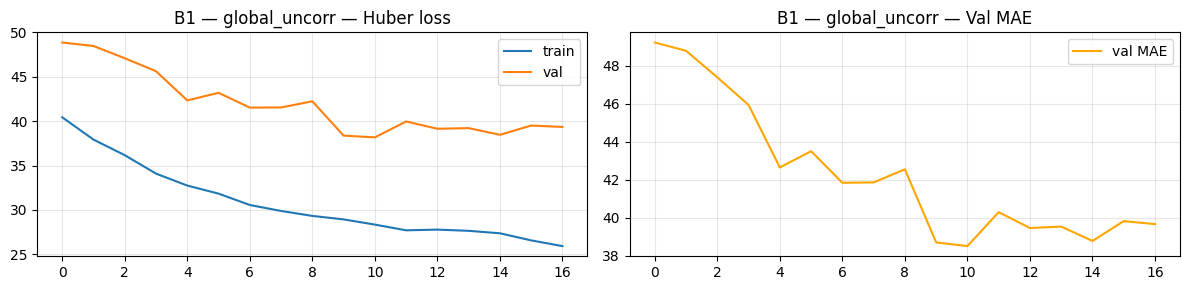

In [20]:
# B1 — set_global_uncorr
print("=== B1: set_global_uncorr ===")
X_tr, y_tr, X_va, y_va, input_size = load_feature_set(FEATURE_SETS["set_global_uncorr"])

model_b1 = CNNForecaster(input_size=input_size,
    num_filters=BEST_A_NUM_FILTERS, kernel_size=BEST_A_KERNEL_SIZE,
    num_layers=BEST_A_NUM_LAYERS, dropout=BEST_A_DROPOUT).to(DEVICE)

tr_loader = DataLoader(TSDataset(X_tr, y_tr), batch_size=BEST_A_BATCH_SIZE, shuffle=True,  num_workers=0)
va_loader = DataLoader(TSDataset(X_va, y_va), batch_size=BEST_A_BATCH_SIZE, shuffle=False, num_workers=0)

mae, rmse, epochs_run, hist = train_and_eval(
    model_b1, tr_loader, va_loader,
    optimizer_name=BEST_A_OPTIMIZER, lr=BEST_A_LR,
    scheduler_name=BEST_A_SCHEDULER, save_path="best_B1.pt")

log_run("B1-01", "B", "CNN", "set_global_uncorr", BEST_A_OPTIMIZER, BEST_A_LR, BEST_A_BATCH_SIZE, epochs_run, mae, rmse)
plot_history(hist, "B1 — global_uncorr")


=== B2: set_h1_uncorr ===
  Aligned ts_index for merge (was int32 vs datetime64[ns]) -> int64
  data/set_h1_uncorr.parquet: 1,394,653 rows | 13 input channels (12 features)
  Train: 53,664 | Val: 2,792 | input_size: 13
  ep   5 | train=31.20963 val=50.09794 MAE=50.42057
  ep  10 | train=31.17008 val=50.16418 MAE=50.48166
  ep  14 | train=31.17158 val=50.10114 MAE=50.42092
  → Early stop at epoch 14
[B2-01] MAE=50.29085  RMSE=256.18515  epochs=14


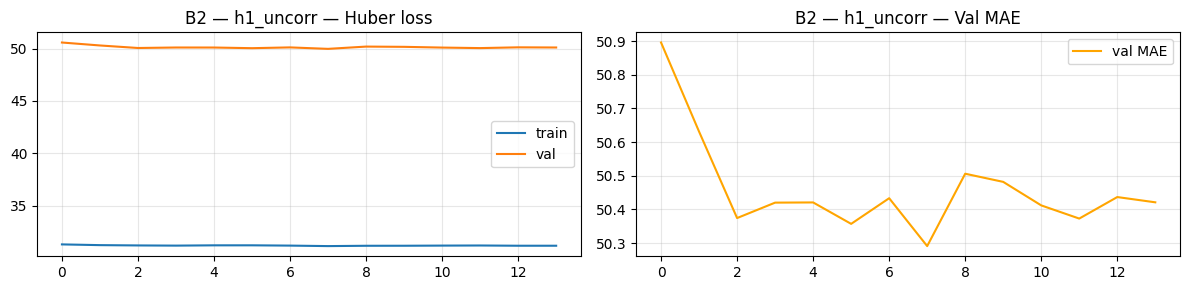

In [21]:
# B2 — set_h1_uncorr
print("=== B2: set_h1_uncorr ===")
X_tr, y_tr, X_va, y_va, input_size = load_feature_set(FEATURE_SETS["set_h1_uncorr"])

model_b2 = CNNForecaster(input_size=input_size,
    num_filters=BEST_A_NUM_FILTERS, kernel_size=BEST_A_KERNEL_SIZE,
    num_layers=BEST_A_NUM_LAYERS, dropout=BEST_A_DROPOUT).to(DEVICE)

tr_loader = DataLoader(TSDataset(X_tr, y_tr), batch_size=BEST_A_BATCH_SIZE, shuffle=True,  num_workers=0)
va_loader = DataLoader(TSDataset(X_va, y_va), batch_size=BEST_A_BATCH_SIZE, shuffle=False, num_workers=0)

mae, rmse, epochs_run, hist = train_and_eval(
    model_b2, tr_loader, va_loader,
    optimizer_name=BEST_A_OPTIMIZER, lr=BEST_A_LR,
    scheduler_name=BEST_A_SCHEDULER, save_path="best_B2.pt")

log_run("B2-01", "B", "CNN", "set_h1_uncorr", BEST_A_OPTIMIZER, BEST_A_LR, BEST_A_BATCH_SIZE, epochs_run, mae, rmse)
plot_history(hist, "B2 — h1_uncorr")


=== B3: set_h3_uncorr ===
  Aligned ts_index for merge (was int32 vs datetime64[ns]) -> int64
  data/set_h3_uncorr.parquet: 1,385,816 rows | 13 input channels (12 features)
  Train: 51,745 | Val: 2,610 | input_size: 13
  ep   5 | train=19.79973 val=22.54303 MAE=22.87318
  ep  10 | train=17.82350 val=21.14717 MAE=21.47651
  ep  15 | train=17.36955 val=21.89168 MAE=22.21980
  ep  17 | train=17.02188 val=22.27605 MAE=22.60051
  → Early stop at epoch 17
[B3-01] MAE=20.81778  RMSE=103.11610  epochs=17


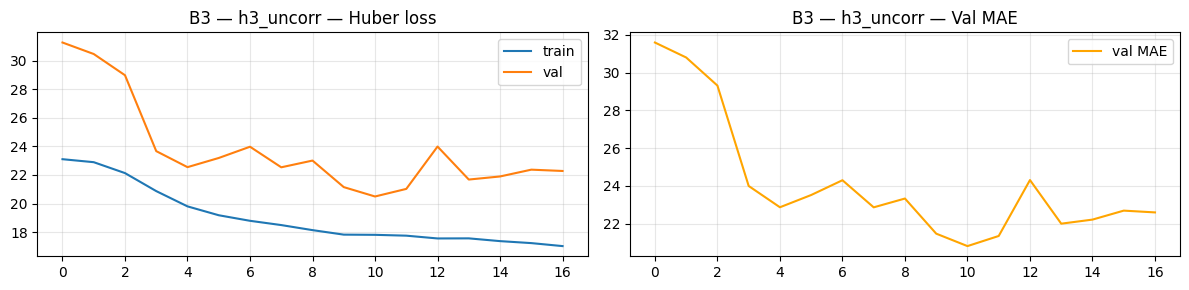

In [22]:
# B3 — set_h3_uncorr
print("=== B3: set_h3_uncorr ===")
X_tr, y_tr, X_va, y_va, input_size = load_feature_set(FEATURE_SETS["set_h3_uncorr"])

model_b3 = CNNForecaster(input_size=input_size,
    num_filters=BEST_A_NUM_FILTERS, kernel_size=BEST_A_KERNEL_SIZE,
    num_layers=BEST_A_NUM_LAYERS, dropout=BEST_A_DROPOUT).to(DEVICE)

tr_loader = DataLoader(TSDataset(X_tr, y_tr), batch_size=BEST_A_BATCH_SIZE, shuffle=True,  num_workers=0)
va_loader = DataLoader(TSDataset(X_va, y_va), batch_size=BEST_A_BATCH_SIZE, shuffle=False, num_workers=0)

mae, rmse, epochs_run, hist = train_and_eval(
    model_b3, tr_loader, va_loader,
    optimizer_name=BEST_A_OPTIMIZER, lr=BEST_A_LR,
    scheduler_name=BEST_A_SCHEDULER, save_path="best_B3.pt")

log_run("B3-01", "B", "CNN", "set_h3_uncorr", BEST_A_OPTIMIZER, BEST_A_LR, BEST_A_BATCH_SIZE, epochs_run, mae, rmse)
plot_history(hist, "B3 — h3_uncorr")


=== B4: set_h10_uncorr ===
  Aligned ts_index for merge (was int32 vs datetime64[ns]) -> int64
  data/set_h10_uncorr.parquet: 1,337,236 rows | 13 input channels (12 features)
  Train: 51,994 | Val: 2,523 | input_size: 13
  ep   5 | train=14.95693 val=16.79887 MAE=17.13783
  ep  10 | train=13.01171 val=14.13345 MAE=14.46646
  ep  15 | train=12.73076 val=13.57758 MAE=13.91006
  ep  20 | train=12.24934 val=14.62068 MAE=14.96499
  ep  21 | train=12.09870 val=14.03844 MAE=14.37184
  → Early stop at epoch 21
[B4-01] MAE=13.91006  RMSE=65.24399  epochs=21


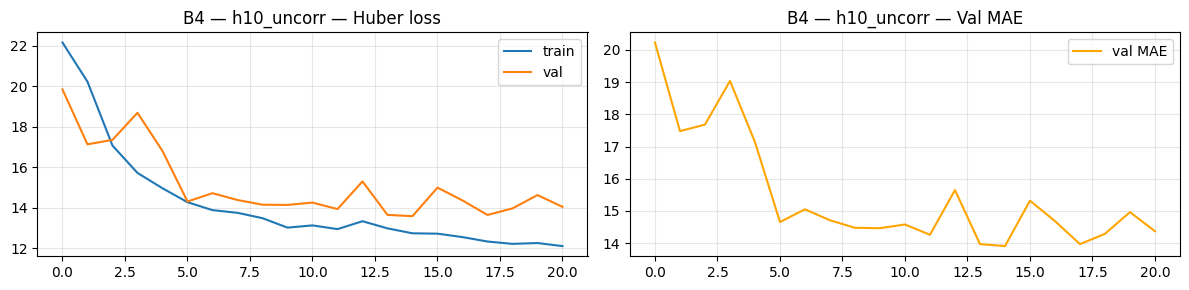

In [23]:
# B4 — set_h10_uncorr
print("=== B4: set_h10_uncorr ===")
X_tr, y_tr, X_va, y_va, input_size = load_feature_set(FEATURE_SETS["set_h10_uncorr"])

model_b4 = CNNForecaster(input_size=input_size,
    num_filters=BEST_A_NUM_FILTERS, kernel_size=BEST_A_KERNEL_SIZE,
    num_layers=BEST_A_NUM_LAYERS, dropout=BEST_A_DROPOUT).to(DEVICE)

tr_loader = DataLoader(TSDataset(X_tr, y_tr), batch_size=BEST_A_BATCH_SIZE, shuffle=True,  num_workers=0)
va_loader = DataLoader(TSDataset(X_va, y_va), batch_size=BEST_A_BATCH_SIZE, shuffle=False, num_workers=0)

mae, rmse, epochs_run, hist = train_and_eval(
    model_b4, tr_loader, va_loader,
    optimizer_name=BEST_A_OPTIMIZER, lr=BEST_A_LR,
    scheduler_name=BEST_A_SCHEDULER, save_path="best_B4.pt")

log_run("B4-01", "B", "CNN", "set_h10_uncorr", BEST_A_OPTIMIZER, BEST_A_LR, BEST_A_BATCH_SIZE, epochs_run, mae, rmse)
plot_history(hist, "B4 — h10_uncorr")


=== B5: set_h25_uncorr ===
  Aligned ts_index for merge (was int32 vs datetime64[ns]) -> int64
  data/set_h25_uncorr.parquet: 1,219,709 rows | 13 input channels (12 features)
  Train: 47,529 | Val: 1,870 | input_size: 13
  ep   5 | train=12.27281 val=11.24529 MAE=11.56799
  ep  10 | train=10.40511 val=9.64118 MAE=9.95808
  ep  15 | train=9.95822 val=9.30448 MAE=9.62416
  ep  20 | train=9.22189 val=9.34402 MAE=9.65415
  ep  25 | train=9.20150 val=9.31487 MAE=9.63283
  ep  27 | train=8.70862 val=9.28210 MAE=9.58296
  → Early stop at epoch 27
[B5-01] MAE=9.35038  RMSE=43.80198  epochs=27


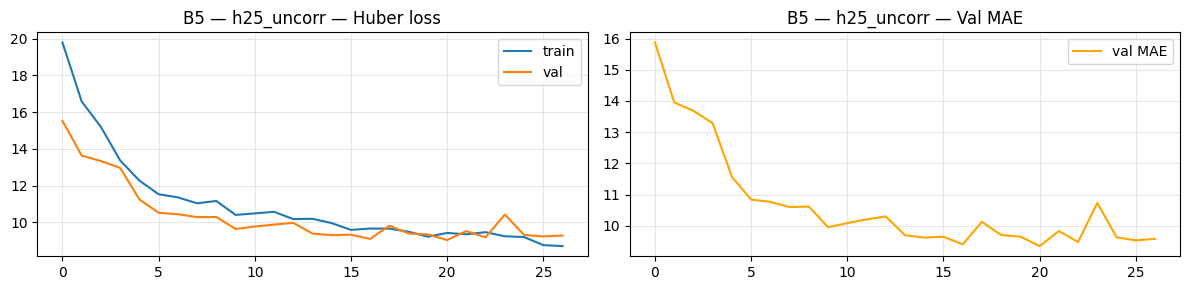

In [24]:
# B5 — set_h25_uncorr
print("=== B5: set_h25_uncorr ===")
X_tr, y_tr, X_va, y_va, input_size = load_feature_set(FEATURE_SETS["set_h25_uncorr"])

model_b5 = CNNForecaster(input_size=input_size,
    num_filters=BEST_A_NUM_FILTERS, kernel_size=BEST_A_KERNEL_SIZE,
    num_layers=BEST_A_NUM_LAYERS, dropout=BEST_A_DROPOUT).to(DEVICE)

tr_loader = DataLoader(TSDataset(X_tr, y_tr), batch_size=BEST_A_BATCH_SIZE, shuffle=True,  num_workers=0)
va_loader = DataLoader(TSDataset(X_va, y_va), batch_size=BEST_A_BATCH_SIZE, shuffle=False, num_workers=0)

mae, rmse, epochs_run, hist = train_and_eval(
    model_b5, tr_loader, va_loader,
    optimizer_name=BEST_A_OPTIMIZER, lr=BEST_A_LR,
    scheduler_name=BEST_A_SCHEDULER, save_path="best_B5.pt")

log_run("B5-01", "B", "CNN", "set_h25_uncorr", BEST_A_OPTIMIZER, BEST_A_LR, BEST_A_BATCH_SIZE, epochs_run, mae, rmse)
plot_history(hist, "B5 — h25_uncorr")


In [25]:
# Block B results
df_log = show_log()
block_b = df_log[df_log["block"] == "B"].sort_values("val_mae")

BEST_B_FEATURE_SET = block_b.iloc[0]["feature_set"]
BEST_B_FILE        = FEATURE_SETS[BEST_B_FEATURE_SET]
print("\n-> Best feature set: " + str(BEST_B_FEATURE_SET) + "  (MAE=" + str(round(block_b.iloc[0]["val_mae"], 5)) + ")")
print("  Carried forward to Block C.")

# Re-load best feature set data for Block C
X_train_best, y_train_best, X_val_best, y_val_best, INPUT_SIZE_BEST = load_feature_set(BEST_B_FILE)


,run_id,block,model,feature_set,optimizer,lr,batch_size,epochs_run,val_mae,val_rmse,extra
0,B5-01,B,CNN,set_h25_uncorr,Adam,0.001,256,27,9.35038,43.80198,
1,B4-01,B,CNN,set_h10_uncorr,Adam,0.001,256,21,13.91006,65.24399,
2,B3-01,B,CNN,set_h3_uncorr,Adam,0.001,256,17,20.81778,103.11610,
3,B1-01,B,CNN,set_global_uncorr,Adam,0.001,256,17,38.50026,221.09093,
4,B2-01,B,CNN,set_h1_uncorr,Adam,0.001,256,14,50.29085,256.18515,



-> Best feature set: set_h25_uncorr  (MAE=9.35038)
  Carried forward to Block C.
  Aligned ts_index for merge (was int32 vs datetime64[ns]) -> int64
  data/set_h25_uncorr.parquet: 1,219,709 rows | 13 input channels (12 features)
  Train: 47,529 | Val: 1,870 | input_size: 13


<a name="2"></a>
## 2 - Block C: Training Hyperparameters

**Fixed:** best CNN from A, best feature set from B.  
**Variable:** one hyperparameter at a time.

| Exp | Variable | Values |
|-----|----------|--------|
| C1  | Optimizer | SGD / Adam / RMSProp |
| C2  | Learning rate | 1e-4 / 1e-3 / 1e-2 |
| C3  | Batch size | 32 / 64 / 128 |
| C4  | LR scheduler | StepLR / CosineAnnealing / ReduceOnPlateau |
| C5  | Early stopping patience | 5 / 10 |

In [26]:
def make_loaders(X_tr, y_tr, X_va, y_va, batch_size):
    """
    Build train and validation DataLoaders.

    Arguments:
    X_tr -- training sequences, numpy array of shape (n, input_size, seq_len)
    y_tr -- training targets, numpy array of shape (n,)
    X_va -- validation sequences, numpy array of shape (m, input_size, seq_len)
    y_va -- validation targets, numpy array of shape (m,)
    batch_size -- mini-batch size, integer

    Returns:
    tr -- DataLoader for the training set
    va -- DataLoader for the validation set
    """
    tr = DataLoader(TSDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=True)
    va = DataLoader(TSDataset(X_va, y_va), batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    return tr, va

def fresh_model():
    """
    Instantiate a new CNNForecaster with the best Block A configuration and a fixed seed.

    Returns:
    model -- CNNForecaster instance moved to DEVICE
    """
    torch.manual_seed(SEED)
    return CNNForecaster(
        input_size  = INPUT_SIZE_BEST,
        num_filters = BEST_A_NUM_FILTERS,
        kernel_size = BEST_A_KERNEL_SIZE,
        num_layers  = BEST_A_NUM_LAYERS,
        dropout     = BEST_A_DROPOUT,
    ).to(DEVICE)


<a name="2-1"></a>
### 2.1 - C1: Optimizer

=== C1: Optimizer ===

-- SGD --
  ep   5 | train=19.23512 val=16.85246 MAE=17.17289
  ep  10 | train=18.15341 val=15.23330 MAE=15.56904
  ep  15 | train=17.45825 val=14.01922 MAE=14.36417
  ep  20 | train=16.99052 val=14.19083 MAE=14.53439
  ep  23 | train=17.06100 val=13.83563 MAE=14.16389
  → Early stop at epoch 23
[C1-SGD] MAE=14.16229  RMSE=66.75869  epochs=23


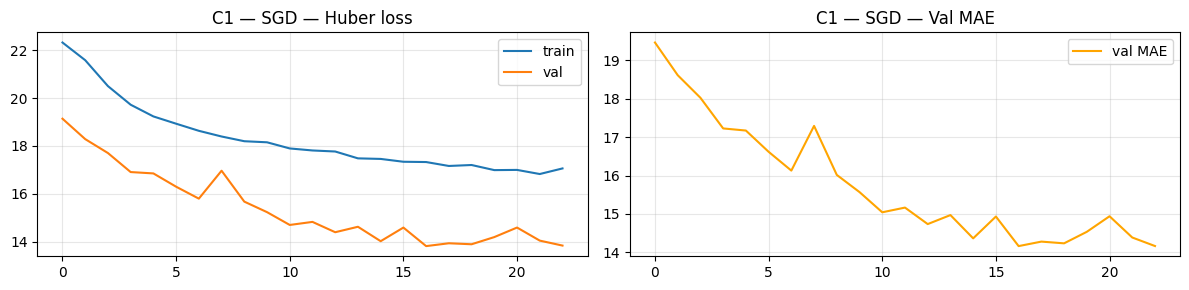


-- Adam --
  ep   5 | train=12.62006 val=11.23262 MAE=11.55078
  ep  10 | train=10.75774 val=9.17667 MAE=9.48469
  ep  15 | train=9.61497 val=9.88716 MAE=10.20053
  ep  16 | train=9.47235 val=9.30075 MAE=9.60994
  → Early stop at epoch 16
[C1-Adam] MAE=9.48469  RMSE=44.57867  epochs=16


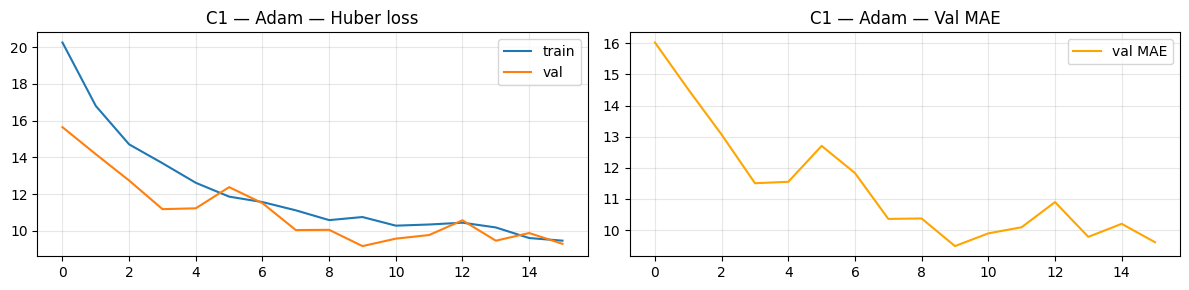


-- RMSProp --
  ep   5 | train=12.20937 val=11.12879 MAE=11.44742
  ep  10 | train=10.70467 val=10.31859 MAE=10.64581
  ep  15 | train=9.55953 val=9.41307 MAE=9.77750
  ep  20 | train=8.74241 val=9.11519 MAE=9.44985
  ep  25 | train=8.84980 val=9.11756 MAE=9.45710
  ep  26 | train=8.59436 val=9.15414 MAE=9.45278
  → Early stop at epoch 26
[C1-RMSProp] MAE=9.44985  RMSE=46.27804  epochs=26


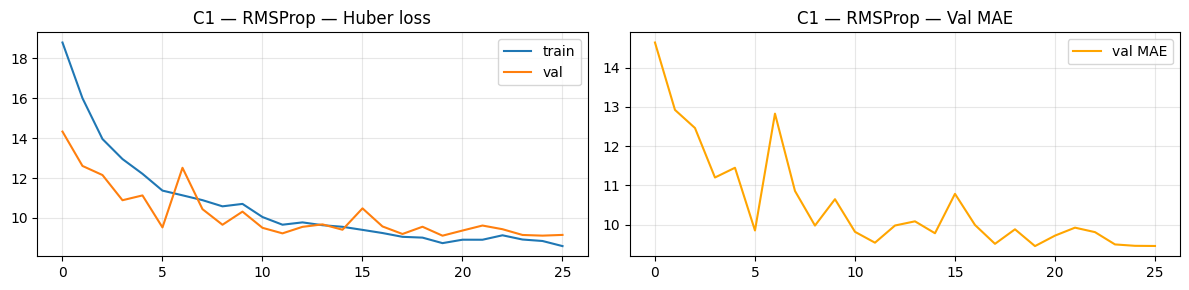

In [27]:
# C1: Optimizer
print("=== C1: Optimizer ===")
tr_loader, va_loader = make_loaders(X_train_best, y_train_best, X_val_best, y_val_best, BEST_A_BATCH_SIZE)

for opt_name in ["SGD", "Adam", "RMSProp"]:
    print(f"\n-- {opt_name} --")
    m = fresh_model()
    mae, rmse, epochs_run, hist = train_and_eval(
        m, tr_loader, va_loader,
        optimizer_name=opt_name, lr=BEST_A_LR,
        scheduler_name=BEST_A_SCHEDULER,
        save_path=f"best_C1_{opt_name}.pt")
    log_run(f"C1-{opt_name}", "C", "CNN", BEST_B_FEATURE_SET, opt_name, BEST_A_LR, BEST_A_BATCH_SIZE, epochs_run, mae, rmse, extra="C1-optimizer")
    plot_history(hist, f"C1 — {opt_name}")


In [28]:
# Pick best optimizer for C2+
df_c1 = pd.DataFrame(results_log)
df_c1 = df_c1[df_c1["extra"] == "C1-optimizer"].sort_values("val_mae")
display(df_c1[["run_id","optimizer","val_mae","val_rmse","epochs_run"]])

BEST_C1_OPTIMIZER = df_c1.iloc[0]["optimizer"]
print("\n-> Best optimizer: " + str(BEST_C1_OPTIMIZER))


,run_id,optimizer,val_mae,val_rmse,epochs_run
7,C1-RMSProp,RMSProp,9.44985,46.27804,26
6,C1-Adam,Adam,9.48469,44.57867,16
5,C1-SGD,SGD,14.16229,66.75869,23



-> Best optimizer: RMSProp


<a name="2-2"></a>
### 2.2 - C2: Learning Rate

=== C2: Learning rate ===

-- lr=0.0001 --
  ep   5 | train=19.18650 val=17.23902 MAE=17.68174
  ep  10 | train=15.67549 val=14.18063 MAE=14.53735
  ep  15 | train=13.33080 val=12.23021 MAE=12.62772
  ep  20 | train=11.88958 val=11.45992 MAE=11.78003
  ep  25 | train=11.20559 val=11.78412 MAE=12.10327
  ep  30 | train=10.83918 val=11.26531 MAE=11.58424
  ep  32 | train=10.49931 val=11.09442 MAE=11.53442
  → Early stop at epoch 32
[C2-lr0.0001] MAE=10.66868  RMSE=50.66882  epochs=32


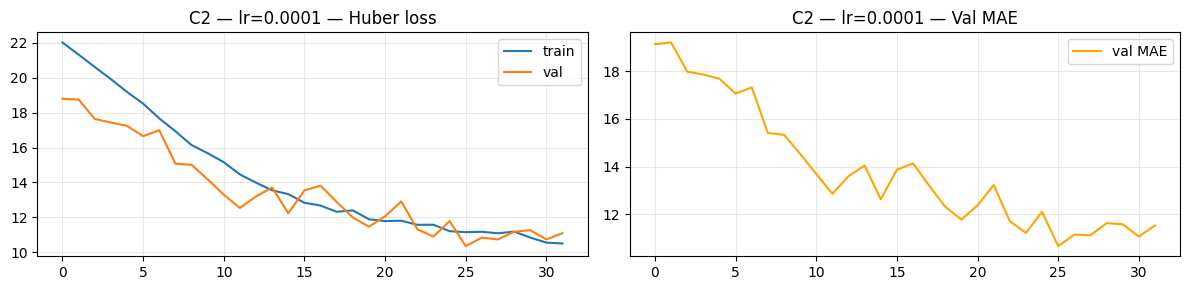


-- lr=0.001 --
  ep   5 | train=12.20937 val=11.12879 MAE=11.44742
  ep  10 | train=10.70467 val=10.31859 MAE=10.64581
  ep  15 | train=9.55953 val=9.41307 MAE=9.77750
  ep  20 | train=8.74241 val=9.11519 MAE=9.44985
  ep  25 | train=8.84980 val=9.11756 MAE=9.45710
  ep  26 | train=8.59436 val=9.15414 MAE=9.45278
  → Early stop at epoch 26
[C2-lr0.001] MAE=9.44985  RMSE=46.27804  epochs=26


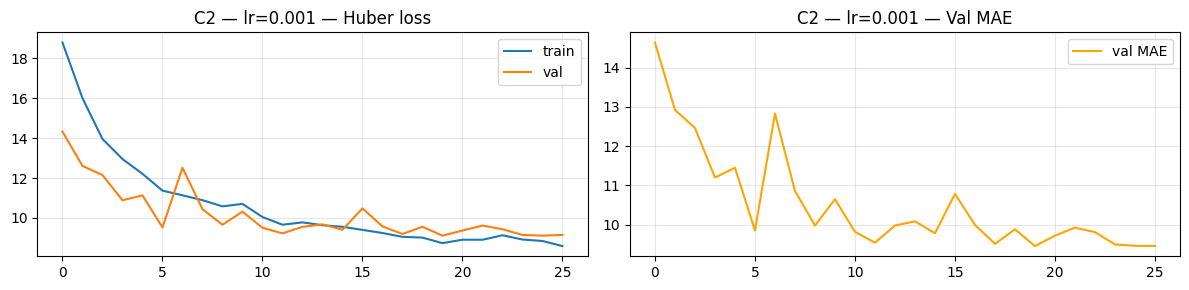


-- lr=0.01 --
  ep   5 | train=11.93981 val=9.72880 MAE=10.04574
  ep  10 | train=10.10733 val=9.55694 MAE=9.86834
  ep  15 | train=9.51257 val=9.16549 MAE=9.47421
  ep  20 | train=8.62112 val=10.28003 MAE=10.72640
  ep  21 | train=8.64919 val=11.13521 MAE=11.59669
  → Early stop at epoch 21
[C2-lr0.01] MAE=9.47421  RMSE=45.89912  epochs=21


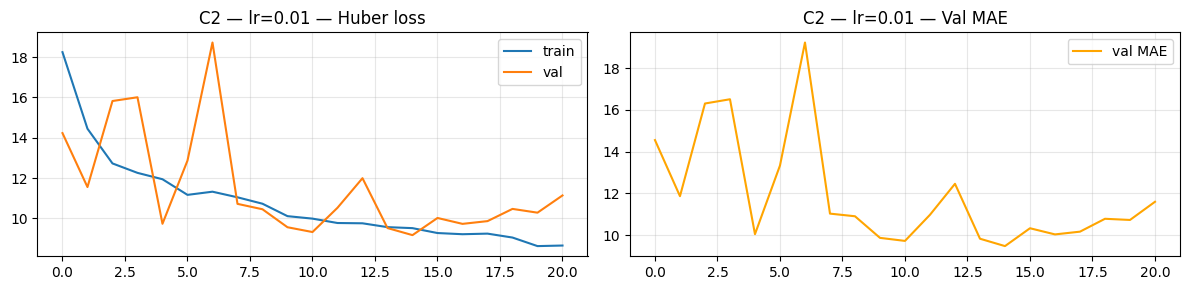

In [29]:
# C2: Learning rate
print("=== C2: Learning rate ===")
tr_loader, va_loader = make_loaders(X_train_best, y_train_best, X_val_best, y_val_best, BEST_A_BATCH_SIZE)

for lr in [1e-4, 1e-3, 1e-2]:
    print(f"\n-- lr={lr} --")
    m = fresh_model()
    mae, rmse, epochs_run, hist = train_and_eval(
        m, tr_loader, va_loader,
        optimizer_name=BEST_C1_OPTIMIZER, lr=lr,
        scheduler_name=BEST_A_SCHEDULER,
        save_path=f"best_C2_lr{lr}.pt")
    log_run(f"C2-lr{lr}", "C", "CNN", BEST_B_FEATURE_SET, BEST_C1_OPTIMIZER, lr, BEST_A_BATCH_SIZE, epochs_run, mae, rmse, extra="C2-lr")
    plot_history(hist, f"C2 — lr={lr}")


In [30]:
df_c2 = pd.DataFrame(results_log)
df_c2 = df_c2[df_c2["extra"] == "C2-lr"].sort_values("val_mae")
display(df_c2[["run_id","lr","val_mae","val_rmse","epochs_run"]])

BEST_C2_LR = df_c2.iloc[0]["lr"]
print("\n-> Best LR: " + str(BEST_C2_LR))


,run_id,lr,val_mae,val_rmse,epochs_run
9,C2-lr0.001,0.0010,9.44985,46.27804,26
10,C2-lr0.01,0.0100,9.47421,45.89912,21
8,C2-lr0.0001,0.0001,10.66868,50.66882,32



-> Best LR: 0.001


<a name="2-3"></a>
### 2.3 - C3: Batch Size

=== C3: Batch size ===

-- batch_size=32 --
  ep   5 | train=11.17099 val=14.25672 MAE=14.58174
  ep  10 | train=9.20647 val=14.77086 MAE=15.09338
  ep  15 | train=8.56527 val=14.11443 MAE=14.42667
  ep  20 | train=8.37188 val=14.46332 MAE=14.79149
  ep  25 | train=8.03807 val=12.12732 MAE=12.44344
  ep  30 | train=7.96311 val=14.18127 MAE=14.50545
  → Early stop at epoch 30
[C3-bs32] MAE=11.55024  RMSE=54.28708  epochs=30


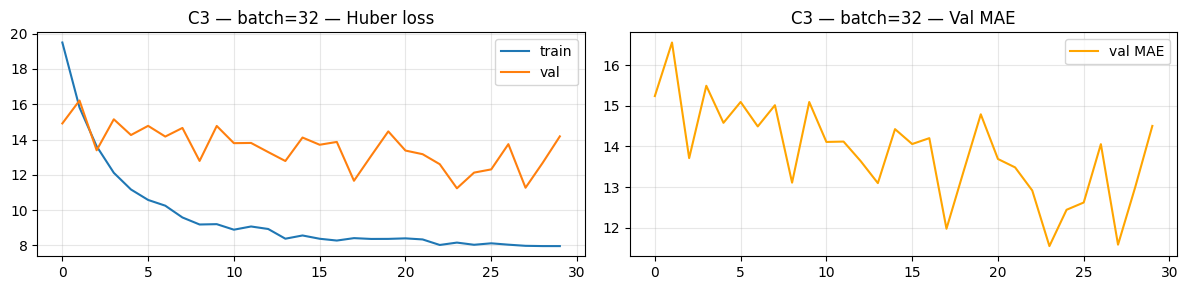


-- batch_size=64 --
  ep   5 | train=12.44809 val=11.75842 MAE=12.08479
  ep  10 | train=10.30679 val=12.63236 MAE=12.94962
  ep  15 | train=8.73297 val=11.42163 MAE=11.73200
  → Early stop at epoch 15
[C3-bs64] MAE=10.94773  RMSE=50.80980  epochs=15


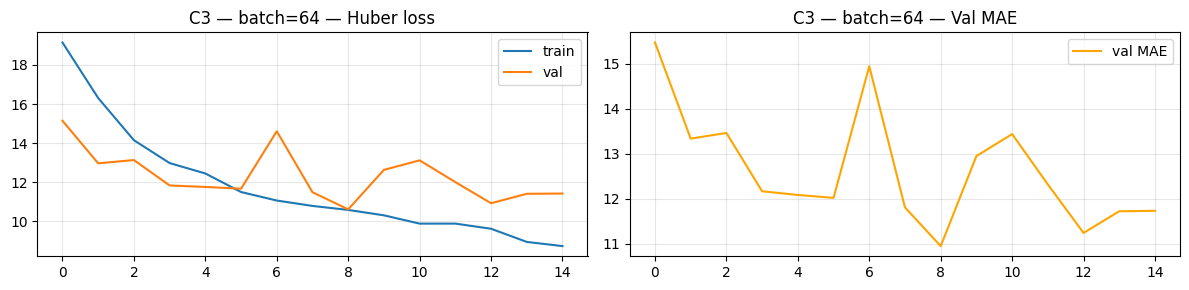


-- batch_size=128 --
  ep   5 | train=12.71250 val=10.49072 MAE=10.80883
  ep  10 | train=10.75496 val=11.51199 MAE=11.83112
  ep  12 | train=9.91610 val=9.89101 MAE=10.21244
  → Early stop at epoch 12
[C3-bs128] MAE=9.98529  RMSE=46.12621  epochs=12


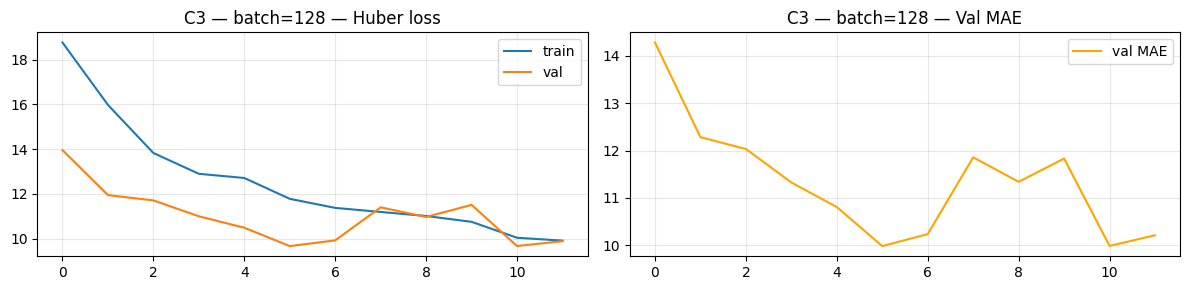

In [31]:
# C3: Batch size
print("=== C3: Batch size ===")

for bs in [32, 64, 128]:
    print(f"\n-- batch_size={bs} --")
    tr_loader, va_loader = make_loaders(X_train_best, y_train_best, X_val_best, y_val_best, bs)
    m = fresh_model()
    mae, rmse, epochs_run, hist = train_and_eval(
        m, tr_loader, va_loader,
        optimizer_name=BEST_C1_OPTIMIZER, lr=BEST_C2_LR,
        scheduler_name=BEST_A_SCHEDULER,
        save_path=f"best_C3_bs{bs}.pt")
    log_run(f"C3-bs{bs}", "C", "CNN", BEST_B_FEATURE_SET, BEST_C1_OPTIMIZER, BEST_C2_LR, bs, epochs_run, mae, rmse, extra="C3-batch")
    plot_history(hist, f"C3 — batch={bs}")


In [32]:
df_c3 = pd.DataFrame(results_log)
df_c3 = df_c3[df_c3["extra"] == "C3-batch"].sort_values("val_mae")
display(df_c3[["run_id","batch_size","val_mae","val_rmse","epochs_run"]])

BEST_C3_BATCH = int(df_c3.iloc[0]["batch_size"])
print("\n-> Best batch size: " + str(BEST_C3_BATCH))


,run_id,batch_size,val_mae,val_rmse,epochs_run
13,C3-bs128,128,9.98529,46.12621,12
12,C3-bs64,64,10.94773,50.80980,15
11,C3-bs32,32,11.55024,54.28708,30



-> Best batch size: 128


<a name="2-4"></a>
### 2.4 - C4: LR Scheduler

=== C4: LR Scheduler ===

-- scheduler=StepLR --
  ep   5 | train=12.71250 val=10.49072 MAE=10.80883
  ep  10 | train=10.75496 val=11.51199 MAE=11.83112
  ep  12 | train=9.91610 val=9.89101 MAE=10.21244
  → Early stop at epoch 12
[C4-StepLR] MAE=9.98529  RMSE=46.12621  epochs=12


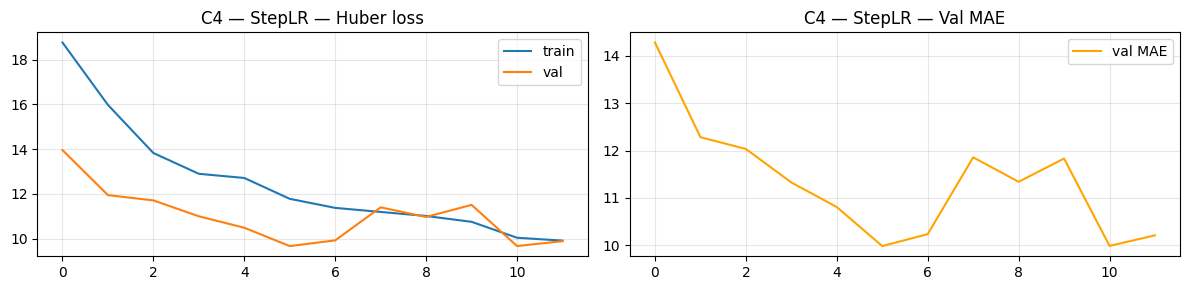


-- scheduler=CosineAnnealing --
  ep   5 | train=12.75137 val=11.06468 MAE=11.38003
  ep  10 | train=10.65092 val=11.63315 MAE=11.94408
  ep  15 | train=9.48355 val=9.62340 MAE=9.98248
  ep  17 | train=9.42674 val=11.34465 MAE=11.78200
  → Early stop at epoch 17
[C4-CosineAnnealing] MAE=9.83819  RMSE=48.22903  epochs=17


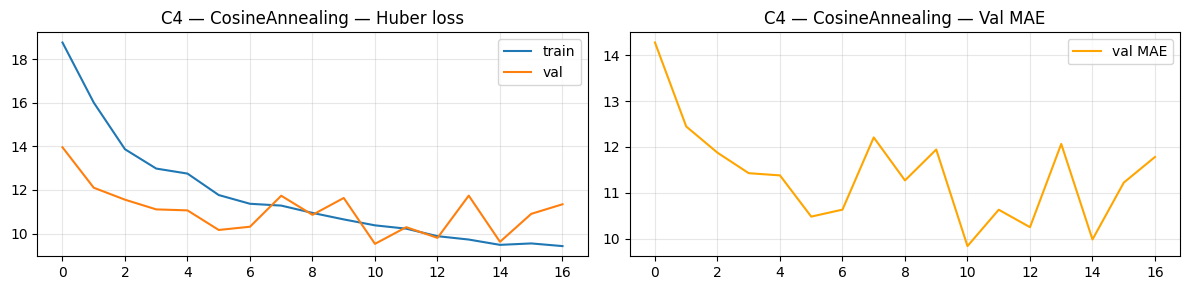


-- scheduler=ReduceOnPlateau --
  ep   5 | train=12.71250 val=10.49072 MAE=10.80883
  ep  10 | train=10.75496 val=11.51199 MAE=11.83112
  ep  12 | train=9.91610 val=9.89101 MAE=10.21244
  → Early stop at epoch 12
[C4-ReduceOnPlateau] MAE=9.98529  RMSE=46.12621  epochs=12


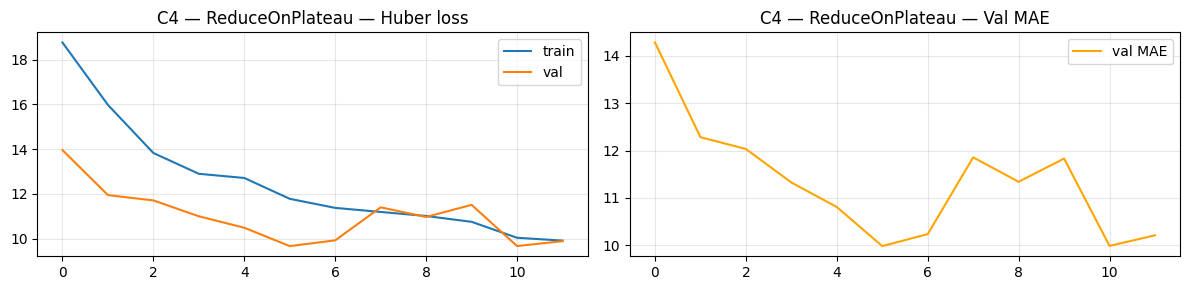

In [33]:
# C4: LR Scheduler
print("=== C4: LR Scheduler ===")
tr_loader, va_loader = make_loaders(X_train_best, y_train_best, X_val_best, y_val_best, BEST_C3_BATCH)

for sched in ["StepLR", "CosineAnnealing", "ReduceOnPlateau"]:
    print(f"\n-- scheduler={sched} --")
    m = fresh_model()
    mae, rmse, epochs_run, hist = train_and_eval(
        m, tr_loader, va_loader,
        optimizer_name=BEST_C1_OPTIMIZER, lr=BEST_C2_LR,
        scheduler_name=sched,
        save_path=f"best_C4_{sched}.pt")
    log_run(f"C4-{sched}", "C", "CNN", BEST_B_FEATURE_SET, BEST_C1_OPTIMIZER, BEST_C2_LR, BEST_C3_BATCH, epochs_run, mae, rmse, extra="C4-scheduler")
    plot_history(hist, f"C4 — {sched}")


In [34]:
df_c4 = pd.DataFrame(results_log)
df_c4 = df_c4[df_c4["extra"] == "C4-scheduler"].sort_values("val_mae")
display(df_c4[["run_id","extra","val_mae","val_rmse","epochs_run"]])

BEST_C4_SCHEDULER = df_c4.iloc[0]["run_id"].replace("C4-", "")
print("\n-> Best scheduler: " + str(BEST_C4_SCHEDULER))


,run_id,extra,val_mae,val_rmse,epochs_run
15,C4-CosineAnnealing,C4-scheduler,9.83819,48.22903,17
14,C4-StepLR,C4-scheduler,9.98529,46.12621,12
16,C4-ReduceOnPlateau,C4-scheduler,9.98529,46.12621,12



-> Best scheduler: CosineAnnealing


<a name="2-5"></a>
### 2.5 - C5: Early Stopping Patience

=== C5: Early stopping patience ===

-- patience=5 --
  ep   5 | train=12.75137 val=11.06468 MAE=11.38003
  ep  10 | train=10.65092 val=11.63315 MAE=11.94408
  ep  15 | train=9.48355 val=9.62340 MAE=9.98248
  ep  16 | train=9.54902 val=10.90501 MAE=11.22176
  → Early stop at epoch 16
[C5-pat5] MAE=9.83819  RMSE=48.22903  epochs=16


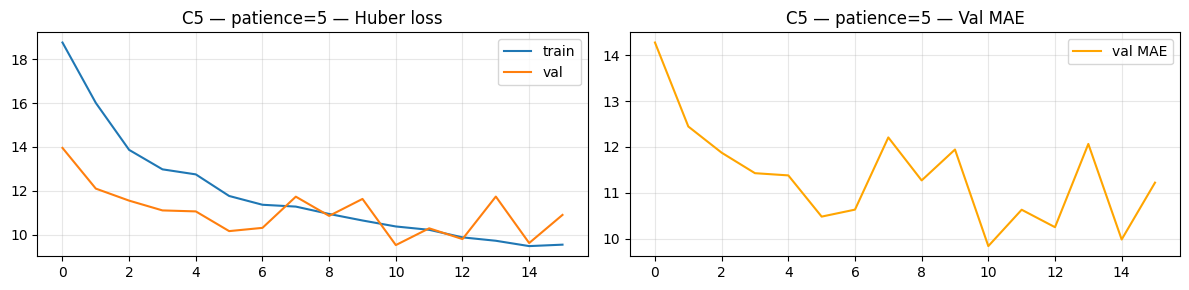


-- patience=10 --
  ep   5 | train=12.75137 val=11.06468 MAE=11.38003
  ep  10 | train=10.65092 val=11.63315 MAE=11.94408
  ep  15 | train=9.48355 val=9.62340 MAE=9.98248
  ep  20 | train=9.02146 val=10.00983 MAE=10.33726
  ep  21 | train=8.88639 val=9.96534 MAE=10.30880
  → Early stop at epoch 21
[C5-pat10] MAE=9.83819  RMSE=48.22903  epochs=21


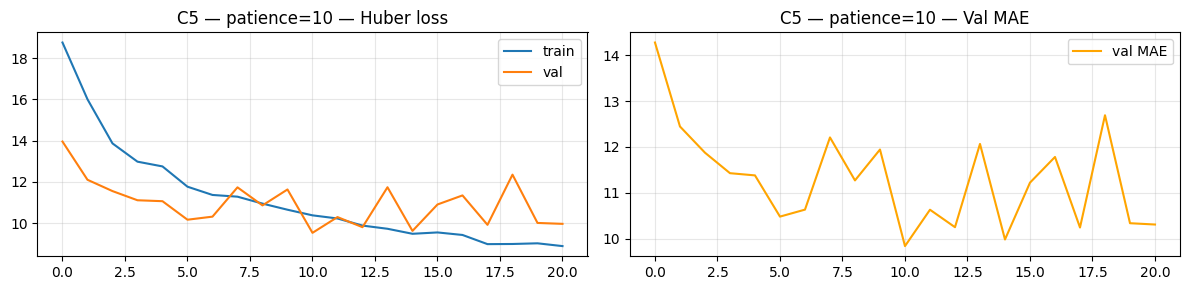

In [35]:
# C5: Early stopping patience
print("=== C5: Early stopping patience ===")
tr_loader, va_loader = make_loaders(X_train_best, y_train_best, X_val_best, y_val_best, BEST_C3_BATCH)

for pat in [5, 10]:
    print(f"\n-- patience={pat} --")
    m = fresh_model()
    mae, rmse, epochs_run, hist = train_and_eval(
        m, tr_loader, va_loader,
        optimizer_name=BEST_C1_OPTIMIZER, lr=BEST_C2_LR,
        scheduler_name=BEST_C4_SCHEDULER,
        patience=pat,
        save_path=f"best_C5_pat{pat}.pt")
    log_run(f"C5-pat{pat}", "C", "CNN", BEST_B_FEATURE_SET, BEST_C1_OPTIMIZER, BEST_C2_LR, BEST_C3_BATCH, epochs_run, mae, rmse, extra=f"C5-patience={pat}")
    plot_history(hist, f"C5 — patience={pat}")


In [36]:
# Block C sammary
df_all = pd.DataFrame(results_log)
block_c = df_all[df_all["block"] == "C"].sort_values("val_mae")
display(block_c[["run_id","extra","optimizer","lr","batch_size","val_mae","val_rmse","epochs_run"]])

best_c = block_c.iloc[0]
BEST_C5_PATIENCE = int(best_c["extra"].split("=")[-1]) if "patience" in best_c["extra"] else PATIENCE
print("\n-> Best Block C config:")
print("   optimizer=" + str(BEST_C1_OPTIMIZER) + ", lr=" + str(BEST_C2_LR) + ", batch=" + str(BEST_C3_BATCH))
print("   scheduler=" + str(BEST_C4_SCHEDULER) + ", patience=" + str(BEST_C5_PATIENCE))


,run_id,extra,optimizer,lr,batch_size,val_mae,val_rmse,epochs_run
7,C1-RMSProp,C1-optimizer,RMSProp,0.0010,256,9.44985,46.27804,26
9,C2-lr0.001,C2-lr,RMSProp,0.0010,256,9.44985,46.27804,26
10,C2-lr0.01,C2-lr,RMSProp,0.0100,256,9.47421,45.89912,21
6,C1-Adam,C1-optimizer,Adam,0.0010,256,9.48469,44.57867,16
15,C4-CosineAnnealing,C4-scheduler,RMSProp,0.0010,128,9.83819,48.22903,17
17,C5-pat5,C5-patience=5,RMSProp,0.0010,128,9.83819,48.22903,16
18,C5-pat10,C5-patience=10,RMSProp,0.0010,128,9.83819,48.22903,21
13,C3-bs128,C3-batch,RMSProp,0.0010,128,9.98529,46.12621,12
14,C4-StepLR,C4-scheduler,RMSProp,0.0010,128,9.98529,46.12621,12
16,C4-ReduceOnPlateau,C4-scheduler,RMSProp,0.0010,128,9.98529,46.12621,12



-> Best Block C config:
   optimizer=RMSProp, lr=0.001, batch=128
   scheduler=CosineAnnealing, patience=6


<a name="3"></a>
## 3 - Block D: Architecture Depth and Regularization

**Fixed:** best config from A + B + C.  
**Variable:** one architectural parameter at a time.

| Exp | Variable | Values |
|-----|----------|--------|
| D1  | Number of layers | 1 / 2 / 3 |
| D2  | Hidden size (num_filters) | 64 / 128 / 256 |
| D3  | Dropout | 0 / 0.2 / 0.5 |
| D4  | Batch normalization | on / off |

In [37]:
# Best training config from C (used for all D experiments)
tr_loader, va_loader = make_loaders(
    X_train_best, y_train_best,
    X_val_best,   y_val_best,
    BEST_C3_BATCH
)

def train_d(model, run_id, extra):
    """
    Train a model with the best Block C configuration and log the result.

    Arguments:
    model -- CNNForecaster instance to train
    run_id -- experiment identifier string, e.g. "D1-layers1"
    extra -- tag string used for filtering results, e.g. "D1-num_layers=1"

    Returns:
    mae -- best validation MAE achieved, scalar
    """
    mae, rmse, epochs_run, hist = train_and_eval(
        model, tr_loader, va_loader,
        optimizer_name = BEST_C1_OPTIMIZER,
        lr             = BEST_C2_LR,
        scheduler_name = BEST_C4_SCHEDULER,
        patience       = BEST_C5_PATIENCE,
        save_path      = f"best_{run_id}.pt")
    log_run(run_id, "D", "CNN", BEST_B_FEATURE_SET,
            BEST_C1_OPTIMIZER, BEST_C2_LR, BEST_C3_BATCH, epochs_run, mae, rmse, extra=extra)
    plot_history(hist, f"{run_id} — {extra}")
    return mae


<a name="3-1"></a>
### 3.1 - D1: Number of Layers

=== D1: Number of ResidualBlocks ===

-- num_layers=1 --
  ep   5 | train=13.75664 val=11.68430 MAE=11.99735
  ep  10 | train=11.32223 val=11.98437 MAE=12.29590
  ep  15 | train=10.13641 val=10.07711 MAE=10.39205
  ep  20 | train=9.75191 val=9.81379 MAE=10.12465
  ep  22 | train=9.26157 val=10.37983 MAE=10.69320
  → Early stop at epoch 22
[D1-layers1] MAE=10.03775  RMSE=47.35689  epochs=22


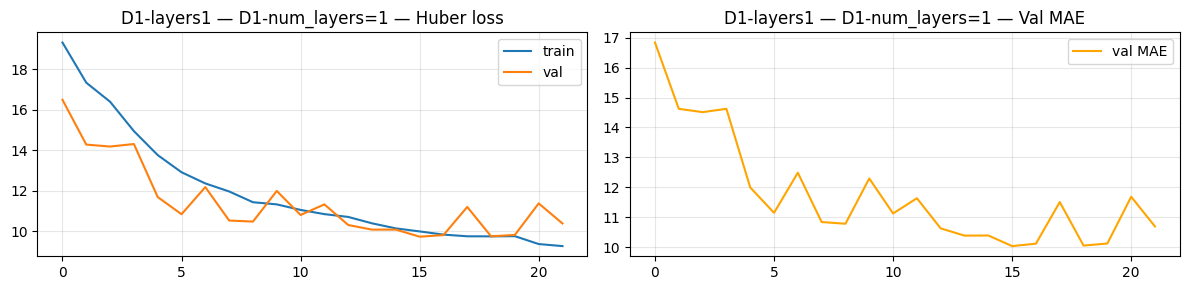


-- num_layers=2 --
  ep   5 | train=13.39494 val=10.84207 MAE=11.17547
  ep  10 | train=10.93123 val=11.12921 MAE=11.44236
  ep  15 | train=10.08240 val=9.71602 MAE=10.02573
  ep  20 | train=9.29296 val=9.92740 MAE=10.24468
  ep  21 | train=9.25670 val=11.07849 MAE=11.38975
  → Early stop at epoch 21
[D1-layers2] MAE=10.02573  RMSE=47.57145  epochs=21


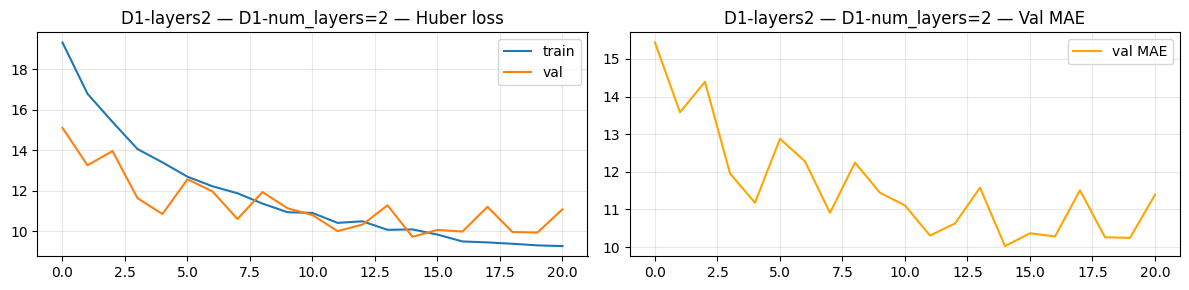


-- num_layers=3 --
  ep   5 | train=12.75137 val=11.06468 MAE=11.38003
  ep  10 | train=10.65092 val=11.63315 MAE=11.94408
  ep  15 | train=9.48355 val=9.62340 MAE=9.98248
  ep  17 | train=9.42674 val=11.34465 MAE=11.78200
  → Early stop at epoch 17
[D1-layers3] MAE=9.83819  RMSE=48.22903  epochs=17


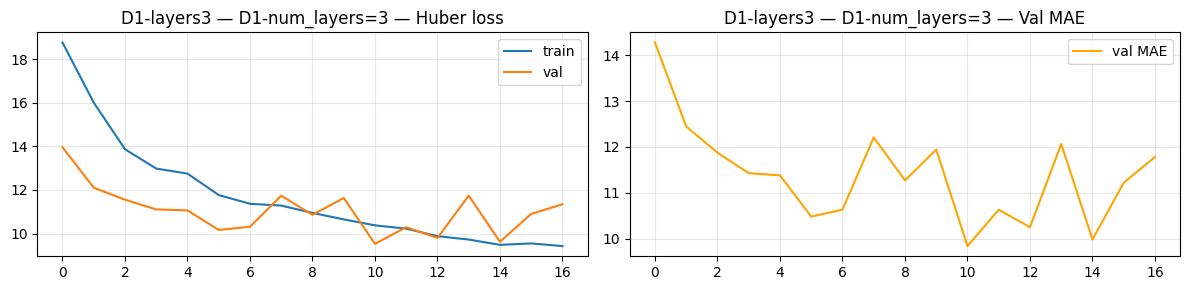

In [38]:
# D1: Number of layers
print("=== D1: Number of ResidualBlocks ===")

for n_layers in [1, 2, 3]:
    print(f"\n-- num_layers={n_layers} --")
    torch.manual_seed(SEED)
    m = CNNForecaster(
        input_size  = INPUT_SIZE_BEST,
        num_filters = BEST_A_NUM_FILTERS,
        kernel_size = BEST_A_KERNEL_SIZE,
        num_layers  = n_layers,
        dropout     = BEST_A_DROPOUT,
    ).to(DEVICE)
    train_d(m, f"D1-layers{n_layers}", f"D1-num_layers={n_layers}")


In [39]:
df_d1 = pd.DataFrame(results_log)
df_d1 = df_d1[df_d1["extra"].str.startswith("D1")].sort_values("val_mae")
display(df_d1[["run_id","extra","val_mae","val_rmse","epochs_run"]])

BEST_D1_LAYERS = int(df_d1.iloc[0]["extra"].split("=")[-1])
print("\n-> Best num_layers: " + str(BEST_D1_LAYERS))


,run_id,extra,val_mae,val_rmse,epochs_run
21,D1-layers3,D1-num_layers=3,9.83819,48.22903,17
20,D1-layers2,D1-num_layers=2,10.02573,47.57145,21
19,D1-layers1,D1-num_layers=1,10.03775,47.35689,22



-> Best num_layers: 3


<a name="3-2"></a>
### 3.2 - D2: Number of Filters

=== D2: num_filters (hidden size) ===

-- num_filters=64 --
   params: 78,017
  ep   5 | train=12.75137 val=11.06468 MAE=11.38003
  ep  10 | train=10.65092 val=11.63315 MAE=11.94408
  ep  15 | train=9.48355 val=9.62340 MAE=9.98248
  ep  17 | train=9.42674 val=11.34465 MAE=11.78200
  → Early stop at epoch 17
[D2-filters64] MAE=9.83819  RMSE=48.22903  epochs=17


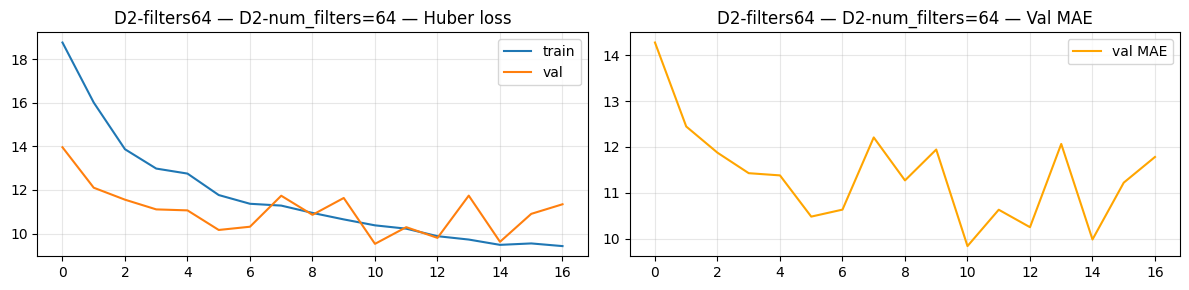


-- num_filters=128 --
   params: 307,585
  ep   5 | train=11.55014 val=10.40921 MAE=10.73788
  ep  10 | train=9.73926 val=10.25489 MAE=10.58997
  ep  15 | train=8.65601 val=9.66061 MAE=9.96620
  → Early stop at epoch 15
[D2-filters128] MAE=9.92382  RMSE=45.81479  epochs=15


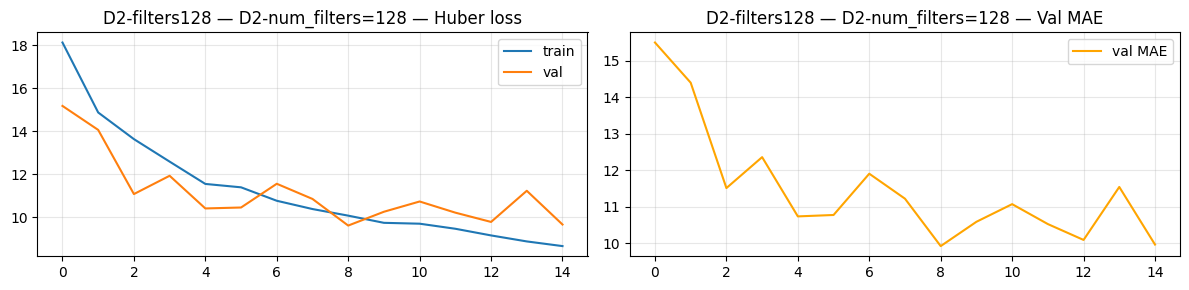


-- num_filters=256 --
   params: 1,221,377
  ep   5 | train=11.30154 val=10.94925 MAE=11.26313
  ep  10 | train=9.44467 val=12.59193 MAE=12.95255
  ep  15 | train=8.47399 val=11.26856 MAE=11.61071
  ep  19 | train=7.89858 val=10.47705 MAE=10.80240
  → Early stop at epoch 19
[D2-filters256] MAE=9.58273  RMSE=46.41196  epochs=19


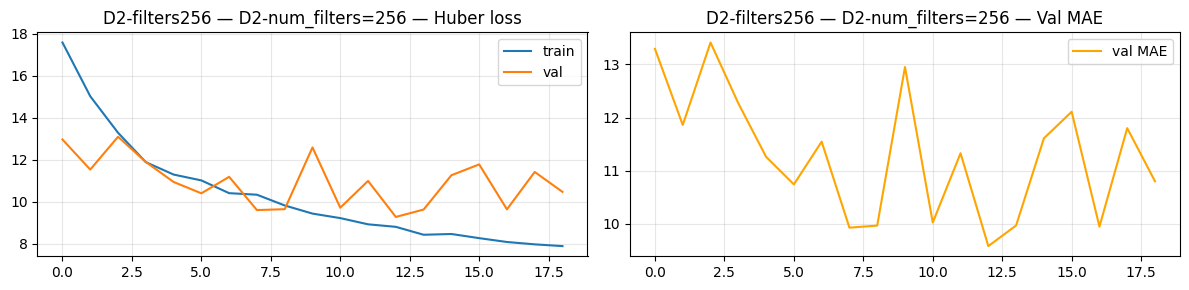

In [40]:
# D2: Hidden size (num_filters)
print("=== D2: num_filters (hidden size) ===")

for nf in [64, 128, 256]:
    print(f"\n-- num_filters={nf} --")
    torch.manual_seed(SEED)
    m = CNNForecaster(
        input_size  = INPUT_SIZE_BEST,
        num_filters = nf,
        kernel_size = BEST_A_KERNEL_SIZE,
        num_layers  = BEST_D1_LAYERS,
        dropout     = BEST_A_DROPOUT,
    ).to(DEVICE)
    print(f"   params: {sum(p.numel() for p in m.parameters() if p.requires_grad):,}")
    train_d(m, f"D2-filters{nf}", f"D2-num_filters={nf}")


In [41]:
df_d2 = pd.DataFrame(results_log)
df_d2 = df_d2[df_d2["extra"].str.startswith("D2")].sort_values("val_mae")
display(df_d2[["run_id","extra","val_mae","val_rmse","epochs_run"]])

BEST_D2_FILTERS = int(df_d2.iloc[0]["extra"].split("=")[-1])
print("\n-> Best num_filters: " + str(BEST_D2_FILTERS))


,run_id,extra,val_mae,val_rmse,epochs_run
24,D2-filters256,D2-num_filters=256,9.58273,46.41196,19
22,D2-filters64,D2-num_filters=64,9.83819,48.22903,17
23,D2-filters128,D2-num_filters=128,9.92382,45.81479,15



-> Best num_filters: 256


<a name="3-3"></a>
### 3.3 - D3: Dropout

=== D3: Dropout ===

-- dropout=0.0 --
  ep   5 | train=10.95642 val=11.65852 MAE=12.14101
  ep  10 | train=9.01851 val=12.24352 MAE=12.69455
  ep  14 | train=8.17806 val=9.65037 MAE=9.99920
  → Early stop at epoch 14
[D3-drop0.0] MAE=9.71504  RMSE=45.41430  epochs=14


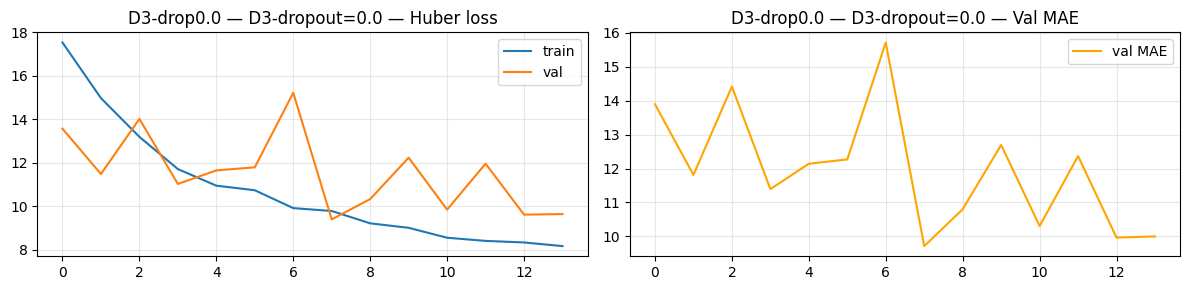


-- dropout=0.2 --
  ep   5 | train=11.30154 val=10.94925 MAE=11.26313
  ep  10 | train=9.44467 val=12.59193 MAE=12.95255
  ep  15 | train=8.47399 val=11.26856 MAE=11.61071
  ep  19 | train=7.89858 val=10.47705 MAE=10.80240
  → Early stop at epoch 19
[D3-drop0.2] MAE=9.58273  RMSE=46.41196  epochs=19


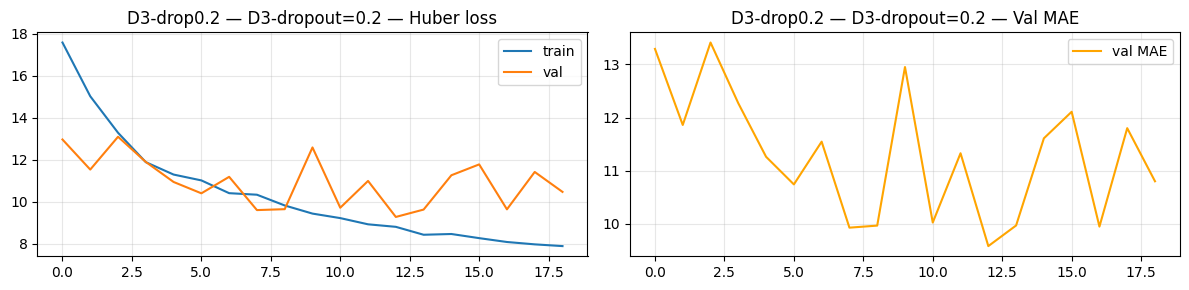


-- dropout=0.5 --
  ep   5 | train=11.95582 val=12.22982 MAE=12.57051
  ep  10 | train=10.04825 val=13.04441 MAE=13.43577
  ep  15 | train=9.15778 val=10.49287 MAE=10.81344
  ep  19 | train=8.65052 val=10.60017 MAE=10.90533
  → Early stop at epoch 19
[D3-drop0.5] MAE=9.74743  RMSE=46.81487  epochs=19


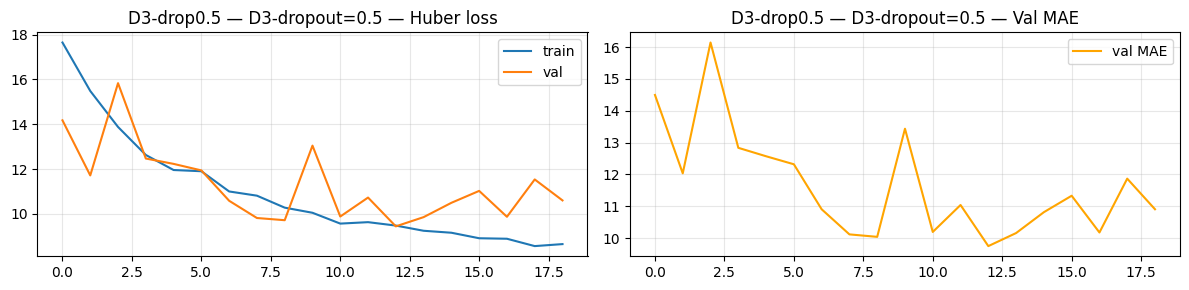

In [42]:
# D3: Dropout
print("=== D3: Dropout ===")

for drop in [0.0, 0.2, 0.5]:
    print(f"\n-- dropout={drop} --")
    torch.manual_seed(SEED)
    m = CNNForecaster(
        input_size  = INPUT_SIZE_BEST,
        num_filters = BEST_D2_FILTERS,
        kernel_size = BEST_A_KERNEL_SIZE,
        num_layers  = BEST_D1_LAYERS,
        dropout     = drop,
    ).to(DEVICE)
    train_d(m, f"D3-drop{drop}", f"D3-dropout={drop}")


In [43]:
df_d3 = pd.DataFrame(results_log)
df_d3 = df_d3[df_d3["extra"].str.startswith("D3")].sort_values("val_mae")
display(df_d3[["run_id","extra","val_mae","val_rmse","epochs_run"]])

BEST_D3_DROPOUT = float(df_d3.iloc[0]["extra"].split("=")[-1])
print("\n-> Best dropout: " + str(BEST_D3_DROPOUT))


,run_id,extra,val_mae,val_rmse,epochs_run
26,D3-drop0.2,D3-dropout=0.2,9.58273,46.41196,19
25,D3-drop0.0,D3-dropout=0.0,9.71504,45.41430,14
27,D3-drop0.5,D3-dropout=0.5,9.74743,46.81487,19



-> Best dropout: 0.2


<a name="3-4"></a>
### 3.4 - D4: Batch Normalization

=== D4: Batch normalization ===

-- BatchNorm=ON --
  ep   5 | train=11.30154 val=10.94925 MAE=11.26313
  ep  10 | train=9.44467 val=12.59193 MAE=12.95255
  ep  15 | train=8.47399 val=11.26856 MAE=11.61071
  ep  19 | train=7.89858 val=10.47705 MAE=10.80240
  → Early stop at epoch 19
[D4-BN-on] MAE=9.58273  RMSE=46.41196  epochs=19


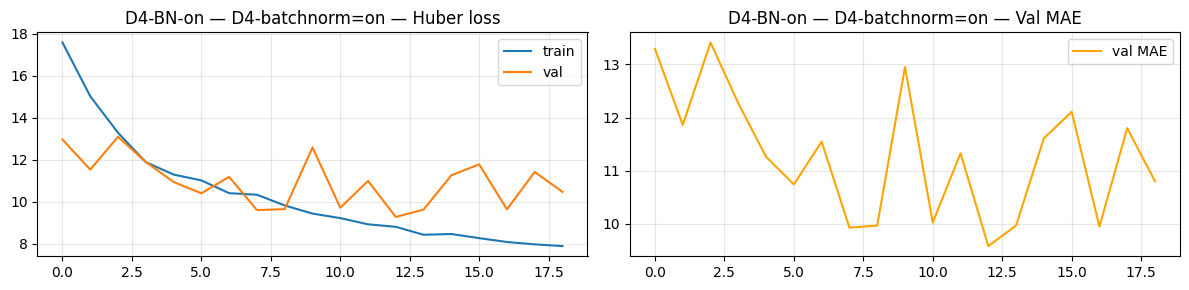


-- BatchNorm=OFF --
  ep   5 | train=8.12534 val=9.18444 MAE=9.44012
  ep  10 | train=7.63356 val=8.97997 MAE=9.22398
  ep  14 | train=7.39634 val=8.86277 MAE=9.11372
  → Early stop at epoch 14
[D4-BN-off] MAE=8.90331  RMSE=43.98249  epochs=14


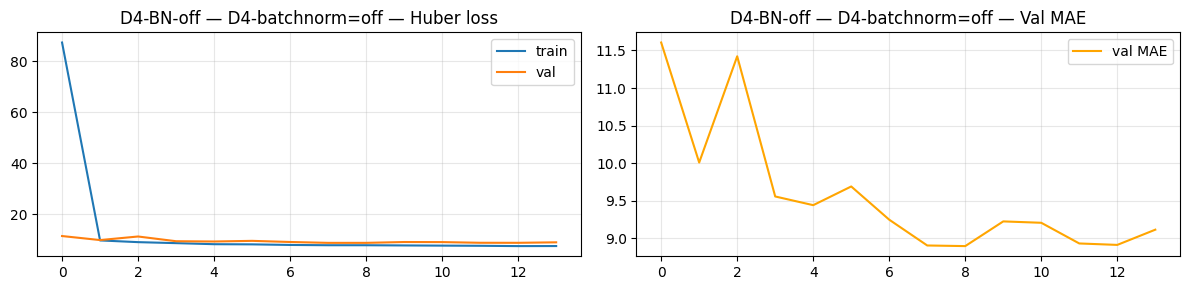

8.90330696105957

In [45]:
# D4: Batch normalization on / off
# This requires a separate model variant without BatchNorm

class ResidualBlockNoBN(nn.Module):
    def __init__(self, channels, kernel_size, dropout):
        """
        Residual block without BatchNorm layers.

        Arguments:
        channels -- number of input and output channels, integer
        kernel_size -- convolutional kernel size, integer
        dropout -- dropout probability, scalar
        """
        super().__init__()
        pad = kernel_size // 2
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, padding=pad),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(channels, channels, kernel_size, padding=pad),
        )
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.relu(x + self.block(x))


class CNNForecasterNoBN(nn.Module):
    """Same as CNNForecaster but without BatchNorm anywhere."""
    def __init__(self, input_size, num_filters, kernel_size, num_layers, dropout):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Conv1d(input_size, num_filters, kernel_size=1),
            nn.ReLU(),
        )
        self.blocks = nn.Sequential(*[
            ResidualBlockNoBN(num_filters, kernel_size, dropout)
            for _ in range(num_layers)
        ])
        self.gap  = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Linear(num_filters, num_filters // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(num_filters // 2, 1),
        )
    def forward(self, x):
        x = self.input_proj(x)
        x = self.blocks(x)
        x = self.gap(x).squeeze(-1)
        return self.head(x).squeeze(-1)


print("=== D4: Batch normalization ===")

# BN on (standard CNNForecaster)
print("\n-- BatchNorm=ON --")
torch.manual_seed(SEED)
m_bn_on = CNNForecaster(
    input_size=INPUT_SIZE_BEST, num_filters=BEST_D2_FILTERS,
    kernel_size=BEST_A_KERNEL_SIZE, num_layers=BEST_D1_LAYERS, dropout=BEST_D3_DROPOUT
).to(DEVICE)
train_d(m_bn_on, "D4-BN-on", "D4-batchnorm=on")

# BN off
print("\n-- BatchNorm=OFF --")
torch.manual_seed(SEED)
m_bn_off = CNNForecasterNoBN(
    input_size=INPUT_SIZE_BEST, num_filters=BEST_D2_FILTERS,
    kernel_size=BEST_A_KERNEL_SIZE, num_layers=BEST_D1_LAYERS, dropout=BEST_D3_DROPOUT
).to(DEVICE)
train_d(m_bn_off, "D4-BN-off", "D4-batchnorm=off")


<a name="4"></a>
## 4 - Summary Table — All Blocks

In [46]:
df_all = pd.DataFrame(results_log)

print("\n== Full experiment log ==")
display(df_all[["run_id","block","feature_set","optimizer","lr","batch_size",
                "val_mae","val_rmse","epochs_run","extra"]]
        .sort_values(["block","val_mae"])
        .reset_index(drop=True))

# Best per block
print("\n== Best config per block ==")
best_per_block = (
    df_all.sort_values("val_mae")
          .groupby("block", sort=False)
          .first()
          .reset_index()
    [["block","run_id","val_mae","val_rmse","extra"]]
)
display(best_per_block)

# Save log
df_all.to_csv("experiment_log.csv", index=False)
print("\nSaved experiment_log.csv")



== Full experiment log ==


,run_id,block,feature_set,optimizer,lr,batch_size,val_mae,val_rmse,epochs_run,extra
0,B5-01,B,set_h25_uncorr,Adam,0.0010,256,9.35038,43.80198,27,
1,B4-01,B,set_h10_uncorr,Adam,0.0010,256,13.91006,65.24399,21,
2,B3-01,B,set_h3_uncorr,Adam,0.0010,256,20.81778,103.11610,17,
3,B1-01,B,set_global_uncorr,Adam,0.0010,256,38.50026,221.09093,17,
4,B2-01,B,set_h1_uncorr,Adam,0.0010,256,50.29085,256.18515,14,
5,C1-RMSProp,C,set_h25_uncorr,RMSProp,0.0010,256,9.44985,46.27804,26,C1-optimizer
6,C2-lr0.001,C,set_h25_uncorr,RMSProp,0.0010,256,9.44985,46.27804,26,C2-lr
7,C2-lr0.01,C,set_h25_uncorr,RMSProp,0.0100,256,9.47421,45.89912,21,C2-lr
8,C1-Adam,C,set_h25_uncorr,Adam,0.0010,256,9.48469,44.57867,16,C1-optimizer
9,C4-CosineAnnealing,C,set_h25_uncorr,RMSProp,0.0010,128,9.83819,48.22903,17,C4-scheduler



== Best config per block ==


,block,run_id,val_mae,val_rmse,extra
0,D,D4-BN-off,8.90331,43.98249,D4-batchnorm=off
1,B,B5-01,9.35038,43.80198,
2,C,C1-RMSProp,9.44985,46.27804,C1-optimizer



Saved experiment_log.csv


In [47]:
# Final best config summary
print("== Best configuration found across all blocks ==")
print("  Feature set   : " + str(BEST_B_FEATURE_SET))
print("  Optimizer     : " + str(BEST_C1_OPTIMIZER))
print("  Learning rate : " + str(BEST_C2_LR))
print("  Batch size    : " + str(BEST_C3_BATCH))
print("  Scheduler     : " + str(BEST_C4_SCHEDULER))
print("  Patience      : " + str(BEST_C5_PATIENCE))
print("  Num layers    : " + str(BEST_D1_LAYERS))
print("  Num filters   : " + str(BEST_D2_FILTERS))
print("  Dropout       : " + str(BEST_D3_DROPOUT))
print()
print("-> Use these values as the fixed config for Stage 4 multi-seed runs.")


== Best configuration found across all blocks ==
  Feature set   : set_h25_uncorr
  Optimizer     : RMSProp
  Learning rate : 0.001
  Batch size    : 128
  Scheduler     : CosineAnnealing
  Patience      : 6
  Num layers    : 3
  Num filters   : 256
  Dropout       : 0.2

-> Use these values as the fixed config for Stage 4 multi-seed runs.
